
# Measurement Submission — Reproducible TinyML Sensor-Health Pipeline

This notebook is a **clean, auditable replacement** for the earlier exploratory notebook.

It is designed to:
- use only NASA C-MAPSS FD001–FD004 training trajectories for the primary experiment;
- keep train/validation/test units disjoint;
- compute health-state accuracy, macro-F1, per-class metrics, ROC-AUC and Average Precision from the same held-out test predictions;
- evaluate **real perturbations applied to the held-out input tensor**;
- export and evaluate a genuine INT8 TensorFlow Lite model;
- run a genuine magnitude-pruning experiment rather than drawing hand-entered pruning curves;
- optionally run QAT if supported by the installed TensorFlow / TFMOT versions;
- clearly separate **measured local-runtime latency** from any hardware-specific claims;
- save all figures, tables, predictions, logs and models into one downloadable ZIP.

> Important: this notebook does **not** fabricate three-node results, STM32H7 measurements, pruning points, temperature-stress curves, or quantisation accuracies. Every plotted value is computed in the notebook.


In [1]:

# ============================================================
# 0. Install dependencies
# ============================================================
!pip -q install -U "tensorflow<2.18" scikit-learn pandas numpy matplotlib tensorflow-model-optimization

import os, sys, time, json, math, random, zipfile, shutil, platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.utils.class_weight import compute_class_weight

print("Python:", sys.version.split()[0])
print("TensorFlow:", tf.__version__)
print("Platform:", platform.platform())


ERROR: Could not find a version that satisfies the requirement tensorflow<2.18 (from versions: 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow<2.18
Python: 3.13.15
TensorFlow: 2.20.0
Platform: Linux-6.6.122+-x86_64-with-glibc2.35


In [2]:

# ============================================================
# 1. Reproducibility and experiment configuration
# ============================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

WINDOW_SIZE = 30
OVERLAP = 0.80
HEALTHY_THR = 120
CRITICAL_THR = 40

TRAIN_RATIO = 0.68
VAL_RATIO = 0.15

CHANNELS = ["Wf", "Nf", "Nc", "T2", "T24", "T30", "T50", "P2", "P30", "Ps30"]
CLASS_NAMES = ["Healthy", "Degrading", "Critical"]

# Energy is NOT directly measured here.
# If retained in the paper, explicitly describe it as E = P_assumed * local_runtime_latency.
ASSUMED_POWER_W = 0.33

OUT = Path("measurement_submission_outputs")
FIG = OUT / "figures"
TAB = OUT / "tables"
ART = OUT / "artifacts"
for p in [OUT, FIG, TAB, ART]:
    p.mkdir(parents=True, exist_ok=True)

print("Output folder:", OUT.resolve())


Output folder: /content/measurement_submission_outputs



## 2. Obtain C-MAPSS data

The cell below first checks whether `train_FD001.txt`–`train_FD004.txt` already exist. It then tries the legacy NASA archive URL. If that fails, upload either:
- `CMAPSSData.zip`, or
- the four `train_FD00x.txt` files directly.

The notebook will stop rather than silently substitute another dataset.


In [4]:
# ============================================================
# 2. Upload and extract NASA C-MAPSS dataset
# ============================================================

import os
import zipfile
from pathlib import Path
from google.colab import files

EXPECTED = [f"train_FD00{i}.txt" for i in range(1, 5)]

def find_train_files():
    found = {}
    for root, dirs, filenames in os.walk("/content"):
        for fn in filenames:
            if fn in EXPECTED:
                found[fn] = os.path.join(root, fn)
    return found


# ------------------------------------------------------------
# STEP 1: Check whether files already exist
# ------------------------------------------------------------
found = find_train_files()

if len(found) < 4:

    print("C-MAPSS training files not found.")
    print()
    print("Please upload either:")
    print("  1. CMAPSSData.zip")
    print("     OR")
    print("  2. train_FD001.txt, train_FD002.txt,")
    print("     train_FD003.txt, train_FD004.txt")
    print()

    uploaded = files.upload()

    # --------------------------------------------------------
    # STEP 2: Extract any uploaded ZIP file
    # --------------------------------------------------------
    for filename in uploaded.keys():

        if filename.lower().endswith(".zip"):

            print(f"\nExtracting {filename} ...")

            try:
                with zipfile.ZipFile(filename, "r") as z:
                    z.extractall("/content/CMAPSS")

                print("Extraction completed.")

            except zipfile.BadZipFile:
                raise RuntimeError(
                    f"{filename} is not a valid ZIP archive."
                )


# ------------------------------------------------------------
# STEP 3: Search recursively again
# ------------------------------------------------------------
found = find_train_files()

print("\nFiles detected:")
for name in EXPECTED:
    if name in found:
        print("✓", name, "->", found[name])
    else:
        print("✗", name)


# ------------------------------------------------------------
# STEP 4: Stop if anything is still missing
# ------------------------------------------------------------
missing = [name for name in EXPECTED if name not in found]

if missing:
    raise FileNotFoundError(
        "\nThe following C-MAPSS files are still missing:\n"
        + "\n".join(missing)
        + "\n\nPlease verify that you downloaded the NASA "
          "CMAPSSData.zip archive."
    )


# ------------------------------------------------------------
# STEP 5: Create ordered file list
# ------------------------------------------------------------
TRAIN_FILES = [found[name] for name in EXPECTED]

print("\nSUCCESS — C-MAPSS dataset is ready.\n")

for path in TRAIN_FILES:
    print(path)

C-MAPSS training files not found.

Please upload either:
  1. CMAPSSData.zip
     OR
  2. train_FD001.txt, train_FD002.txt,
     train_FD003.txt, train_FD004.txt



Saving CMAPSSData.zip to CMAPSSData (2).zip

Extracting CMAPSSData (2).zip ...
Extraction completed.

Files detected:
✓ train_FD001.txt -> /content/CMAPSS/train_FD001.txt
✓ train_FD002.txt -> /content/CMAPSS/train_FD002.txt
✓ train_FD003.txt -> /content/CMAPSS/train_FD003.txt
✓ train_FD004.txt -> /content/CMAPSS/train_FD004.txt

SUCCESS — C-MAPSS dataset is ready.

/content/CMAPSS/train_FD001.txt
/content/CMAPSS/train_FD002.txt
/content/CMAPSS/train_FD003.txt
/content/CMAPSS/train_FD004.txt


In [5]:

# ============================================================
# 3. Load FD001–FD004 and compute RUL
# ============================================================
columns = [
    "unit_id","cycle","op1","op2","op3",
    "T2","T24","T30","T50","P2","P15","P30",
    "Nf","Nc","epr","Ps30","phi","NRf","NRc","BPR","farB",
    "htBleed","Nf_dmd","PCNfR_dmd","W31","W32"
]

dfs = []
for file_path in TRAIN_FILES:
    subset = Path(file_path).stem.replace("train_", "")
    temp = pd.read_csv(file_path, sep=r"\s+", header=None)
    temp = temp.iloc[:, :len(columns)]
    temp.columns = columns

    temp["unit_id"] = temp["unit_id"].astype(int)
    temp["global_unit_id"] = subset + "_" + temp["unit_id"].astype(str)

    max_cycle = temp.groupby("global_unit_id")["cycle"].transform("max")
    temp["RUL"] = max_cycle - temp["cycle"]

    # W31 is retained as the proxy input used by the original executed notebook.
    temp["Wf"] = temp["W31"]
    temp["subset"] = subset
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)
df = df[["global_unit_id","cycle","subset"] + CHANNELS + ["RUL"]].copy()
df = df.rename(columns={"global_unit_id":"unit_id"})

print("Combined rows:", len(df))
print("Units:", df["unit_id"].nunique())
display(df.head())


Combined rows: 160359
Units: 709


,unit_id,cycle,subset,Wf,Nf,Nc,T2,T24,T30,T50,P2,P30,Ps30,RUL
0,FD001_1,1,FD001,39.06,2388.06,9046.19,518.67,641.82,1589.70,1400.60,14.62,554.36,47.47,191
1,FD001_1,2,FD001,39.00,2388.04,9044.07,518.67,642.15,1591.82,1403.14,14.62,553.75,47.49,190
2,FD001_1,3,FD001,38.95,2388.08,9052.94,518.67,642.35,1587.99,1404.20,14.62,554.26,47.27,189
3,FD001_1,4,FD001,38.88,2388.11,9049.48,518.67,642.35,1582.79,1401.87,14.62,554.45,47.13,188
4,FD001_1,5,FD001,38.90,2388.06,9055.15,518.67,642.37,1582.85,1406.22,14.62,554.00,47.28,187


In [6]:

# ============================================================
# 4. Unit-wise split, training-only normalisation, windows
# ============================================================
def rul_to_class(rul):
    if rul > HEALTHY_THR:
        return 0
    if rul < CRITICAL_THR:
        return 2
    return 1

units = np.array(sorted(df["unit_id"].unique()))
rng_split = np.random.default_rng(SEED)
rng_split.shuffle(units)

n = len(units)
n_train = int(TRAIN_RATIO*n)
n_val = int(VAL_RATIO*n)

train_units = units[:n_train]
val_units = units[n_train:n_train+n_val]
test_units = units[n_train+n_val:]

assert set(train_units).isdisjoint(val_units)
assert set(train_units).isdisjoint(test_units)
assert set(val_units).isdisjoint(test_units)

train_df = df[df.unit_id.isin(train_units)].copy()
val_df   = df[df.unit_id.isin(val_units)].copy()
test_df  = df[df.unit_id.isin(test_units)].copy()

scaler = StandardScaler().fit(train_df[CHANNELS])
for frame in (train_df, val_df, test_df):
    frame.loc[:, CHANNELS] = scaler.transform(frame[CHANNELS])

def make_windows(frame):
    stride = max(1, int(WINDOW_SIZE*(1-OVERLAP)))
    X, yc, yr, uid = [], [], [], []
    for unit, g in frame.groupby("unit_id"):
        g = g.sort_values("cycle")
        values = g[CHANNELS].to_numpy(np.float32)
        ruls = g["RUL"].to_numpy(np.float32)
        for start in range(0, len(g)-WINDOW_SIZE+1, stride):
            end = start + WINDOW_SIZE
            rul = float(ruls[end-1])
            X.append(values[start:end])
            yc.append(rul_to_class(rul))
            yr.append(rul)
            uid.append(unit)
    return np.asarray(X,np.float32), np.asarray(yc,np.int64), np.asarray(yr,np.float32), np.asarray(uid)

X_train,y_train,rul_train,uid_train = make_windows(train_df)
X_val,y_val,rul_val,uid_val = make_windows(val_df)
X_test,y_test,rul_test,uid_test = make_windows(test_df)

split_summary = pd.DataFrame({
    "Split":["Train","Validation","Test"],
    "Units":[len(train_units),len(val_units),len(test_units)],
    "Windows":[len(X_train),len(X_val),len(X_test)],
    "Healthy":[(y_train==0).sum(),(y_val==0).sum(),(y_test==0).sum()],
    "Degrading":[(y_train==1).sum(),(y_val==1).sum(),(y_test==1).sum()],
    "Critical":[(y_train==2).sum(),(y_val==2).sum(),(y_test==2).sum()],
})
display(split_summary)
split_summary.to_csv(TAB/"dataset_split.csv", index=False)

pd.DataFrame({"train_unit_id":pd.Series(train_units)}).to_csv(ART/"train_units.csv",index=False)
pd.DataFrame({"val_unit_id":pd.Series(val_units)}).to_csv(ART/"val_units.csv",index=False)
pd.DataFrame({"test_unit_id":pd.Series(test_units)}).to_csv(ART/"test_units.csv",index=False)

pd.DataFrame({"channel":CHANNELS,"mean":scaler.mean_,"scale":scaler.scale_}).to_csv(
    ART/"scaler_statistics.csv", index=False
)


,Split,Units,Windows,Healthy,Degrading,Critical
0,Train,482,19304,7686,7762,3856
1,Validation,106,4212,1653,1711,848
2,Test,121,4715,1788,1959,968


In [7]:

# ============================================================
# 5. Model definition
# ============================================================
from tensorflow.keras import layers, models

def sep_tcn_block(x, filters, kernel_size=5, dilation=1, dropout=0.15):
    shortcut = x
    x = layers.SeparableConv1D(
        filters, kernel_size, padding="same",
        dilation_rate=dilation, use_bias=False
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(dropout)(x)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding="same", use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    return layers.Activation("relu")(x)

def build_model():
    inp = layers.Input((WINDOW_SIZE,len(CHANNELS)), name="sensor_window")
    x = layers.Conv1D(16,1,padding="same",use_bias=False)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = sep_tcn_block(x,80,dilation=1)
    x = sep_tcn_block(x,56,dilation=2)
    x = sep_tcn_block(x,200,dilation=4)
    x = layers.GlobalAveragePooling1D()(x)
    emb = layers.Dense(128,activation="relu",name="shared_embedding")(x)
    health = layers.Dense(3,activation="softmax",name="health_state")(emb)
    anomaly = layers.Dense(1,activation="linear",name="anomaly_score")(emb)
    return models.Model(inp,[health,anomaly],name="tinyml_sensor_health")

def compile_model(m, lr=1e-3):
    m.compile(
        optimizer=tf.keras.optimizers.AdamW(lr),
        loss={"health_state":"sparse_categorical_crossentropy","anomaly_score":"mse"},
        loss_weights={"health_state":1.0,"anomaly_score":0.1},
        metrics={"health_state":["accuracy"]}
    )
    return m

model = compile_model(build_model())
model.summary()
print("Trainable parameters:", model.count_params())


Model: "tinyml_sensor_health"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sensor_window       │ (None, 30, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 30, 16)    │        160 │ sensor_window[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 30, 16)    │         64 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 30, 16)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv1d    │ (None, 30, 80)    │      1,360 │ activation[0][0]  │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 80)    │        320 │ separable_conv1d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 30, 80)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 30, 80)    │      1,280 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 30, 80)    │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 80)    │        320 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 80)    │          0 │ dropout[0][0],    │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 30, 80)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv1d_1  │ (None, 30, 56)    │      4,880 │ activation_2[0][… │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 56)    │        224 │ separable_conv1d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 30, 56)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 30, 56)    │      4,480 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 30, 56)    │          0 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 56)    │        224 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 63,836 (249.36 KB)

 Trainable params: 62,460 (243.98 KB)

 Non-trainable params: 1,376 (5.38 KB)

Trainable parameters: 63836


In [8]:

# ============================================================
# 6. Training
# ============================================================
anomaly_train = (y_train>0).astype("float32")
anomaly_val = (y_val>0).astype("float32")

classes = np.unique(y_train)
cw_vals = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = dict(zip(classes,cw_vals))
sample_weight_cls = np.asarray([class_weight[int(y)] for y in y_train],np.float32)
sample_weight_anom = np.ones(len(y_train),np.float32)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_health_state_accuracy", patience=10,
        mode="max", restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        ART/"best_model.keras",
        monitor="val_health_state_accuracy",
        mode="max", save_best_only=True
    )
]

history = model.fit(
    X_train,[y_train,anomaly_train],
    sample_weight=[sample_weight_cls,sample_weight_anom],
    validation_data=(X_val,[y_val,anomaly_val]),
    epochs=100,batch_size=32,callbacks=callbacks,verbose=1
)

best_model = tf.keras.models.load_model(ART/"best_model.keras")


Epoch 1/100
604/604 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - anomaly_score_loss: 0.1891 - health_state_accuracy: 0.6434 - health_state_loss: 0.6821 - loss: 0.7008 - val_anomaly_score_loss: 0.2589 - val_health_state_accuracy: 0.5916 - val_health_state_loss: 0.8311 - val_loss: 0.8533
Epoch 2/100
604/604 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - anomaly_score_loss: 0.1574 - health_state_accuracy: 0.6860 - health_state_loss: 0.6081 - loss: 0.6236 - val_anomaly_score_loss: 0.2051 - val_health_state_accuracy: 0.6344 - val_health_state_loss: 0.7457 - val_loss: 0.7635
Epoch 3/100
604/604 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - anomaly_score_loss: 0.1498 - health_state_accuracy: 0.7021 - health_state_loss: 0.5759 - loss: 0.5905 - val_anomaly_score_loss: 0.1579 - val_health_state_accuracy: 0.6954 - val_health_state_loss: 0.6371 - val_loss: 0.6509
Epoch 4/100
604/604 ━━━━━━━━━━━━━━━━━━━━ 40s 35ms/step - anomaly_score_loss: 0.1434 - health_state_accuracy: 0.7198 - health_state_loss: 0.5438 - loss: 0.5577 - va

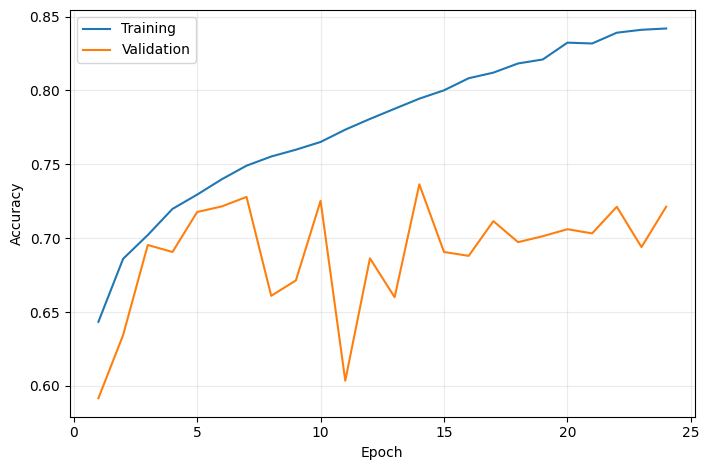

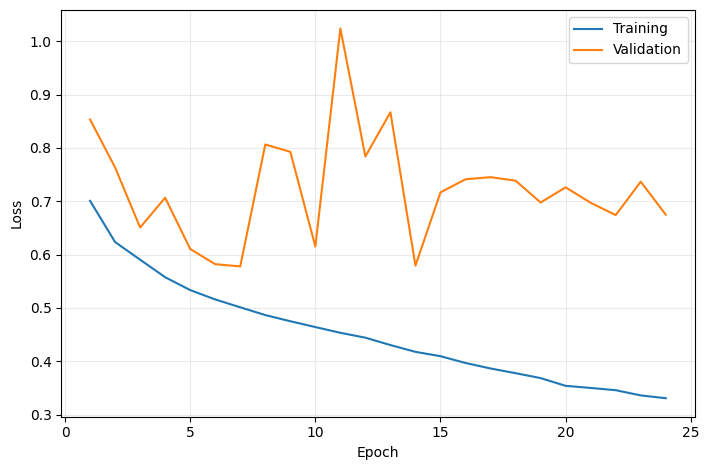

In [9]:

# ============================================================
# 7. Figure 5 — genuine training curves
# ============================================================
hist = pd.DataFrame(history.history)
hist.to_csv(TAB/"training_history.csv",index=False)

fig, ax = plt.subplots(figsize=(7.2,4.8))
ax.plot(hist.index+1, hist["health_state_accuracy"], label="Training")
ax.plot(hist.index+1, hist["val_health_state_accuracy"], label="Validation")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.legend(); ax.grid(alpha=.25)
fig.tight_layout()
fig.savefig(FIG/"Figure5a_training_accuracy.png",dpi=600,bbox_inches="tight")
fig.savefig(FIG/"Figure5a_training_accuracy.pdf",bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7.2,4.8))
ax.plot(hist.index+1, hist["loss"], label="Training")
ax.plot(hist.index+1, hist["val_loss"], label="Validation")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(); ax.grid(alpha=.25)
fig.tight_layout()
fig.savefig(FIG/"Figure5b_training_loss.png",dpi=600,bbox_inches="tight")
fig.savefig(FIG/"Figure5b_training_loss.pdf",bbox_inches="tight")
plt.show()


,Health State,Precision (%),Recall (%),F1-score (%),Support
0,Healthy,67.28,85.79,75.42,1788
1,Degrading,76.71,53.29,62.89,1959
2,Critical,83.05,92.15,87.37,968
3,Macro average,75.68,77.08,75.22,4715
4,Weighted average,74.44,73.59,72.67,4715


Health-state accuracy: 73.5949%
Macro-F1: 75.2249%
Binary anomaly ROC-AUC: 0.875787
Average Precision: 0.928024


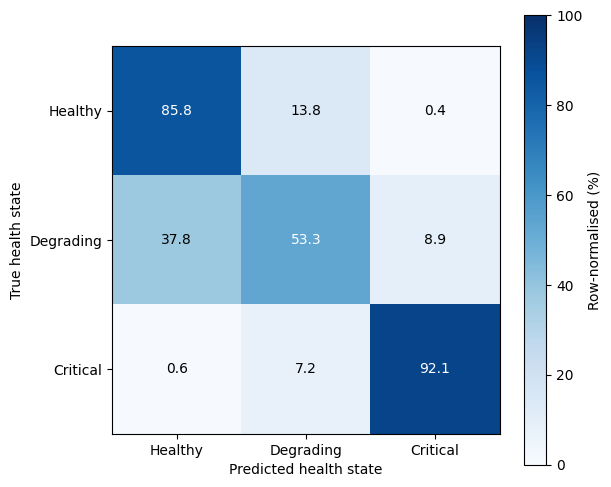

In [10]:

# ============================================================
# 8. Held-out test evaluation + Table 12 + Figure 6
# ============================================================
cls_probs, anomaly_head = best_model.predict(X_test, verbose=0)
y_pred = np.argmax(cls_probs,axis=1)

y_anomaly = (y_test>0).astype(int)
score_anomaly = 1.0-cls_probs[:,0]

accuracy = accuracy_score(y_test,y_pred)
macro_f1 = f1_score(y_test,y_pred,average="macro")
roc_auc = roc_auc_score(y_anomaly,score_anomaly)
ap = average_precision_score(y_anomaly,score_anomaly)

report = classification_report(
    y_test,y_pred,target_names=CLASS_NAMES,
    output_dict=True,zero_division=0
)

rows=[]
for name in CLASS_NAMES:
    r=report[name]
    rows.append([name,100*r["precision"],100*r["recall"],100*r["f1-score"],int(r["support"])])
for label,key in [("Macro average","macro avg"),("Weighted average","weighted avg")]:
    r=report[key]
    rows.append([label,100*r["precision"],100*r["recall"],100*r["f1-score"],int(r["support"])])
table12=pd.DataFrame(rows,columns=["Health State","Precision (%)","Recall (%)","F1-score (%)","Support"])
display(table12.round(2))
table12.to_csv(TAB/"Table12_classification_report.csv",index=False)

print(f"Health-state accuracy: {accuracy*100:.4f}%")
print(f"Macro-F1: {macro_f1*100:.4f}%")
print(f"Binary anomaly ROC-AUC: {roc_auc:.6f}")
print(f"Average Precision: {ap:.6f}")

cm = confusion_matrix(y_test,y_pred,normalize="true")*100
fig,ax=plt.subplots(figsize=(6.2,5.2))
im=ax.imshow(cm,cmap="Blues",vmin=0,vmax=100)
ax.set_xticks(range(3),CLASS_NAMES); ax.set_yticks(range(3),CLASS_NAMES)
ax.set_xlabel("Predicted health state"); ax.set_ylabel("True health state")
for i in range(3):
    for j in range(3):
        ax.text(j,i,f"{cm[i,j]:.1f}",ha="center",va="center",
                color="white" if cm[i,j]>50 else "black")
fig.colorbar(im,ax=ax,label="Row-normalised (%)")
fig.tight_layout()
fig.savefig(FIG/"Figure6_confusion_matrix.png",dpi=600,bbox_inches="tight")
fig.savefig(FIG/"Figure6_confusion_matrix.pdf",bbox_inches="tight")
plt.show()

np.savez_compressed(
    ART/"heldout_predictions.npz",
    y_test=y_test,y_pred=y_pred,cls_probs=cls_probs,
    y_anomaly=y_anomaly,score_anomaly=score_anomaly,
    rul_test=rul_test,unit_id=uid_test
)


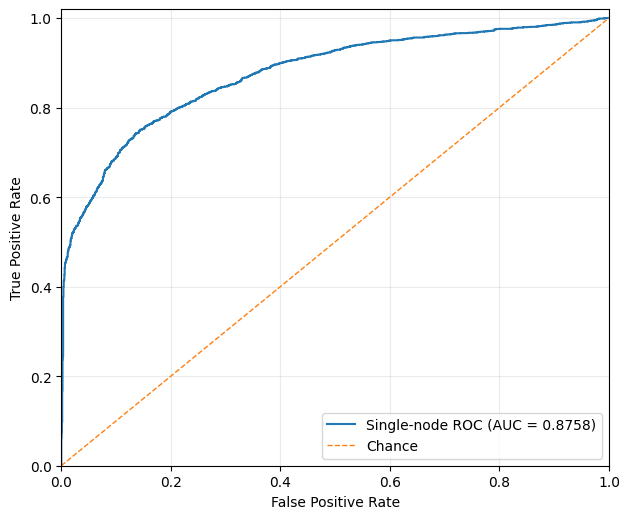

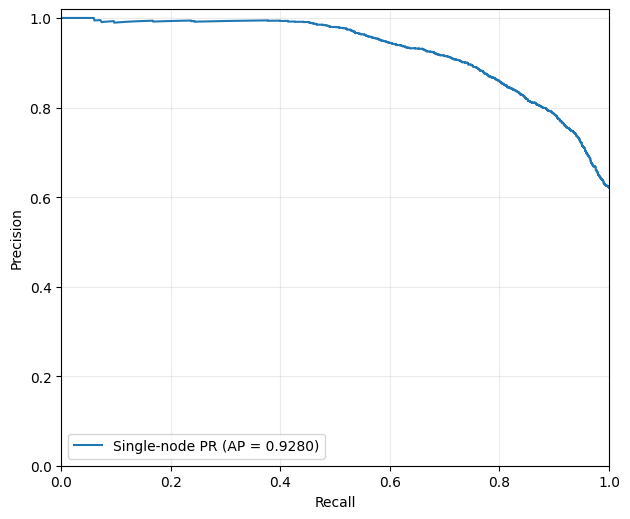

In [11]:

# ============================================================
# 9. Figure 13 — genuine SINGLE-NODE ROC + PR only
# ============================================================
fpr,tpr,_ = roc_curve(y_anomaly,score_anomaly)
precision,recall,_ = precision_recall_curve(y_anomaly,score_anomaly)

fig,ax=plt.subplots(figsize=(6.4,5.3))
ax.plot(fpr,tpr,label=f"Single-node ROC (AUC = {roc_auc:.4f})")
ax.plot([0,1],[0,1],"--",linewidth=1,label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_xlim(0,1); ax.set_ylim(0,1.02)
ax.grid(alpha=.25); ax.legend()
fig.tight_layout()
fig.savefig(FIG/"Figure13a_ROC_single_node.png",dpi=600,bbox_inches="tight")
fig.savefig(FIG/"Figure13a_ROC_single_node.pdf",bbox_inches="tight")
plt.show()

fig,ax=plt.subplots(figsize=(6.4,5.3))
ax.plot(recall,precision,label=f"Single-node PR (AP = {ap:.4f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_xlim(0,1); ax.set_ylim(0,1.02)
ax.grid(alpha=.25); ax.legend()
fig.tight_layout()
fig.savefig(FIG/"Figure13b_PR_single_node.png",dpi=600,bbox_inches="tight")
fig.savefig(FIG/"Figure13b_PR_single_node.pdf",bbox_inches="tight")
plt.show()

pd.DataFrame({"fpr":fpr,"tpr":tpr}).to_csv(TAB/"roc_curve.csv",index=False)
pd.DataFrame({"recall":recall,"precision":precision}).to_csv(TAB/"pr_curve.csv",index=False)


,Condition,AUC (%),Macro-F1 (%),Accuracy (%)
0,Clean,87.58,75.22,73.59
1,Noise (20 dB SNR),73.97,46.26,46.17
2,Dropout (5%),72.74,44.61,44.69
3,Temporal jitter,86.15,72.49,70.63


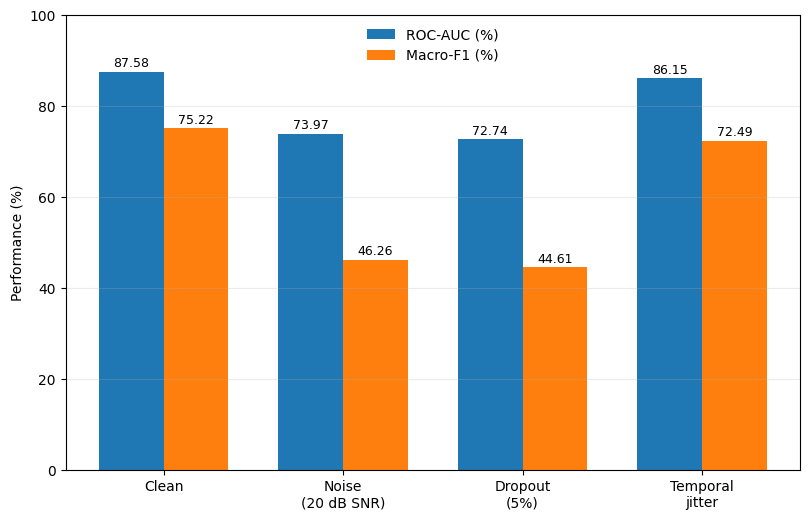

In [12]:

# ============================================================
# 10. Genuine operational perturbation tests — Table 11 / 15 + Figure 11
# ============================================================
rng = np.random.default_rng(SEED+100)

def add_noise_snr(X,snr_db=20,rng=None):
    rng = np.random.default_rng() if rng is None else rng
    signal_power = np.mean(X**2,axis=(1,2),keepdims=True)
    noise_power = signal_power/(10**(snr_db/10))
    noise = rng.normal(0,1,X.shape).astype(np.float32)*np.sqrt(noise_power).astype(np.float32)
    return (X+noise).astype(np.float32)

def apply_dropout(X,rate=.05,rng=None):
    rng = np.random.default_rng() if rng is None else rng
    mask=(rng.random(X.shape)>=rate).astype(np.float32)
    return (X*mask).astype(np.float32)

def temporal_jitter(X,max_shift=3,rng=None):
    rng=np.random.default_rng() if rng is None else rng
    out=np.empty_like(X)
    for i in range(len(X)):
        shift=int(rng.integers(-max_shift,max_shift+1))
        out[i]=np.roll(X[i],shift,axis=0)
    return out

def evaluate_X(Xv):
    probs,_=best_model.predict(Xv,verbose=0)
    pred=np.argmax(probs,axis=1)
    return {
        "AUC (%)":100*roc_auc_score(y_anomaly,1-probs[:,0]),
        "Macro-F1 (%)":100*f1_score(y_test,pred,average="macro"),
        "Accuracy (%)":100*accuracy_score(y_test,pred)
    }

robustness = []
variants = [
    ("Clean",X_test),
    ("Noise (20 dB SNR)",add_noise_snr(X_test,20,rng)),
    ("Dropout (5%)",apply_dropout(X_test,.05,rng)),
    ("Temporal jitter",temporal_jitter(X_test,3,rng)),
]
for name,Xv in variants:
    d=evaluate_X(Xv); d["Condition"]=name; robustness.append(d)

robust_df=pd.DataFrame(robustness)[["Condition","AUC (%)","Macro-F1 (%)","Accuracy (%)"]]
display(robust_df.round(2))
robust_df.to_csv(TAB/"Table11_robustness.csv",index=False)

x=np.arange(len(robust_df)); w=.36
fig,ax=plt.subplots(figsize=(8.2,5.3))
b1=ax.bar(x-w/2,robust_df["AUC (%)"],w,label="ROC-AUC (%)")
b2=ax.bar(x+w/2,robust_df["Macro-F1 (%)"],w,label="Macro-F1 (%)")
ax.set_xticks(x,["Clean","Noise\n(20 dB SNR)","Dropout\n(5%)","Temporal\njitter"])
ax.set_ylabel("Performance (%)"); ax.set_ylim(0,100)
ax.legend(frameon=False); ax.grid(axis="y",alpha=.25)
for bars in [b1,b2]:
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2,b.get_height()+1,f"{b.get_height():.2f}",
                ha="center",fontsize=9)
fig.tight_layout()
fig.savefig(FIG/"Figure11_robustness.png",dpi=600,bbox_inches="tight")
fig.savefig(FIG/"Figure11_robustness.pdf",bbox_inches="tight")
plt.show()


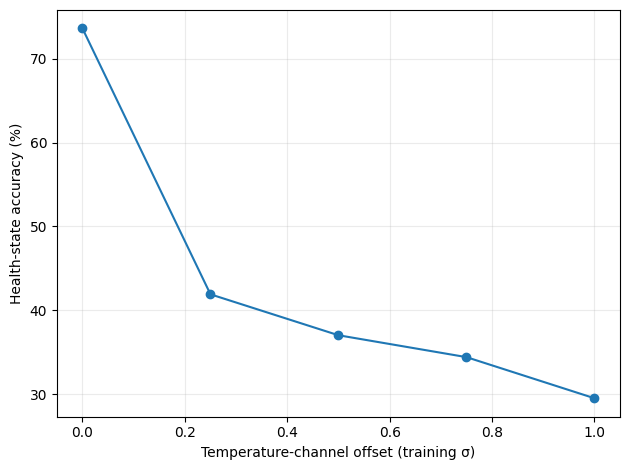

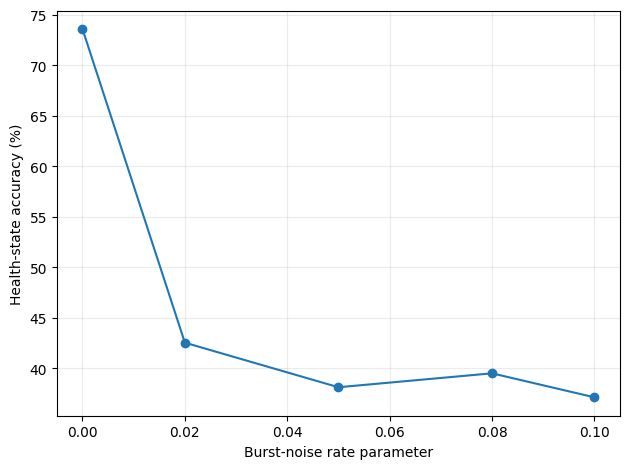

In [13]:

# ============================================================
# 11. Genuine stress tests — Figure 12
# Temperature-channel offset is expressed in TRAINING STANDARD DEVIATIONS,
# not claimed as a physical °C chamber test.
# ============================================================
temp_channels = [CHANNELS.index(c) for c in ["T2","T24","T30","T50"]]

def temperature_channel_shift(X,shift_sigma):
    Xs=X.copy()
    Xs[:,:,temp_channels]+=shift_sigma
    return Xs.astype(np.float32)

def burst_noise(X,burst_rate=.05,amp_sigma=1.0,rng=None):
    rng=np.random.default_rng() if rng is None else rng
    out=X.copy()
    n_time=X.shape[1]
    burst_len=max(1,int(round(.15*n_time)))
    n_bursts=max(1,int(round(burst_rate*n_time)))
    for i in range(len(out)):
        for _ in range(n_bursts):
            start=int(rng.integers(0,max(1,n_time-burst_len+1)))
            out[i,start:start+burst_len,:]+=rng.normal(
                0,amp_sigma,(burst_len,X.shape[2])
            ).astype(np.float32)
    return out

temp_levels=[0,.25,.5,.75,1.0]
temp_rows=[]
for s in temp_levels:
    d=evaluate_X(temperature_channel_shift(X_test,s))
    temp_rows.append({"Temperature-channel offset (sigma)":s,**d})
temp_df=pd.DataFrame(temp_rows)
temp_df.to_csv(TAB/"temperature_channel_shift.csv",index=False)

burst_levels=[0,.02,.05,.08,.10]
burst_rows=[]
for br in burst_levels:
    Xv=X_test if br==0 else burst_noise(X_test,br,1.0,np.random.default_rng(SEED+int(br*1000)))
    d=evaluate_X(Xv)
    burst_rows.append({"Burst-rate parameter":br,**d})
burst_df=pd.DataFrame(burst_rows)
burst_df.to_csv(TAB/"burst_noise_stress.csv",index=False)

fig,ax=plt.subplots(figsize=(6.4,4.8))
ax.plot(temp_df["Temperature-channel offset (sigma)"],temp_df["Accuracy (%)"],marker="o")
ax.set_xlabel("Temperature-channel offset (training σ)")
ax.set_ylabel("Health-state accuracy (%)")
ax.grid(alpha=.25)
fig.tight_layout()
fig.savefig(FIG/"Figure12a_temperature_channel_shift.png",dpi=600,bbox_inches="tight")
fig.savefig(FIG/"Figure12a_temperature_channel_shift.pdf",bbox_inches="tight")
plt.show()

fig,ax=plt.subplots(figsize=(6.4,4.8))
ax.plot(burst_df["Burst-rate parameter"],burst_df["Accuracy (%)"],marker="o")
ax.set_xlabel("Burst-noise rate parameter")
ax.set_ylabel("Health-state accuracy (%)")
ax.grid(alpha=.25)
fig.tight_layout()
fig.savefig(FIG/"Figure12b_burst_noise.png",dpi=600,bbox_inches="tight")
fig.savefig(FIG/"Figure12b_burst_noise.pdf",bbox_inches="tight")
plt.show()


In [14]:

# ============================================================
# 12. Genuine INT8 PTQ export + evaluation
# ============================================================
def representative_dataset():
    for i in range(min(500,len(X_val))):
        yield [X_val[i:i+1].astype(np.float32)]

converter=tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations=[tf.lite.Optimize.DEFAULT]
converter.representative_dataset=representative_dataset
converter.target_spec.supported_ops=[tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type=tf.int8
converter.inference_output_type=tf.int8
tflite_int8=converter.convert()

int8_path=ART/"tinyml_sensor_health_int8.tflite"
int8_path.write_bytes(tflite_int8)
int8_size_kb=int8_path.stat().st_size/1024

def tflite_predict(model_bytes,X):
    interpreter=tf.lite.Interpreter(model_content=model_bytes)
    interpreter.allocate_tensors()
    inp=interpreter.get_input_details()[0]
    outs=interpreter.get_output_details()

    health_probs=[]
    anomaly_vals=[]
    in_scale,in_zero=inp["quantization"]

    for i in range(len(X)):
        xi=X[i:i+1]
        if inp["dtype"]==np.int8:
            q=np.round(xi/in_scale+in_zero).clip(-128,127).astype(np.int8)
        else:
            q=xi.astype(inp["dtype"])
        interpreter.set_tensor(inp["index"],q)
        interpreter.invoke()

        vals=[]
        for od in outs:
            v=interpreter.get_tensor(od["index"])
            sc,zp=od["quantization"]
            if od["dtype"]==np.int8 and sc>0:
                v=(v.astype(np.float32)-zp)*sc
            vals.append(v)

        # Identify 3-class output by trailing dimension = 3
        hp=next(v for v in vals if v.shape[-1]==3)
        av=next((v for v in vals if v.shape[-1]==1),np.zeros((1,1),np.float32))
        health_probs.append(hp[0])
        anomaly_vals.append(float(av.reshape(-1)[0]))

    return np.asarray(health_probs),np.asarray(anomaly_vals)

int8_probs,int8_anom=tflite_predict(tflite_int8,X_test)
int8_pred=np.argmax(int8_probs,axis=1)
int8_acc=accuracy_score(y_test,int8_pred)
int8_f1=f1_score(y_test,int8_pred,average="macro")
int8_auc=roc_auc_score(y_anomaly,1-int8_probs[:,0])

print("INT8 size (kB):",round(int8_size_kb,2))
print("INT8 accuracy (%):",round(100*int8_acc,3))
print("INT8 macro-F1 (%):",round(100*int8_f1,3))
print("INT8 ROC-AUC:",round(int8_auc,6))


Saved artifact at '/tmp/tmpy4bu5xp2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 30, 10), dtype=tf.float32, name='sensor_window')
Output Type:
  List[TensorSpec(shape=(None, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)]
Captures:
  140393055129232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140393055130000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140393055129808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140393055129040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140393055126160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140393055128272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140393055125968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140393055132880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140393055132304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140393055126544: TensorS

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


INT8 size (kB): 102.69
INT8 accuracy (%): 49.926
INT8 macro-F1 (%): 44.322
INT8 ROC-AUC: 0.757686


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


,Configuration,Accuracy (%),Macro-F1 (%),ROC-AUC,Model size / weight footprint (kB),Local runtime latency (ms),Estimated energy @ 0.33 W (mJ)
0,FP32 Keras,73.5949,75.2249,0.8758,249.3594,44.5108,14.6885
1,INT8 TFLite,49.9258,44.3216,0.7577,102.6875,0.0696,0.0230


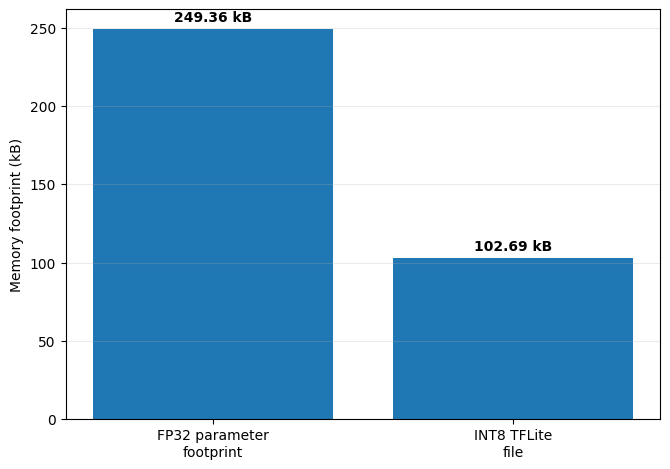

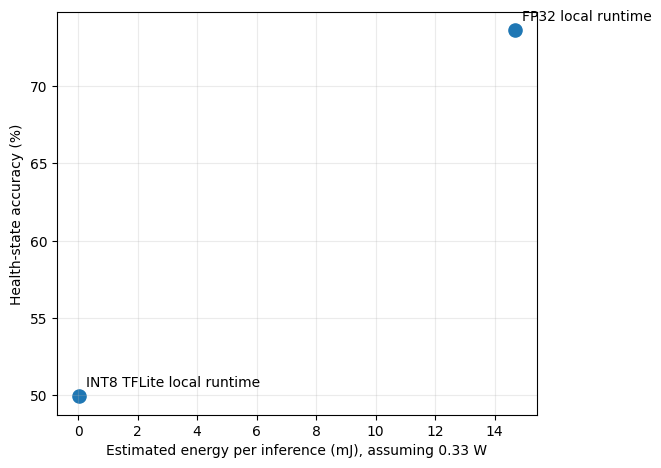

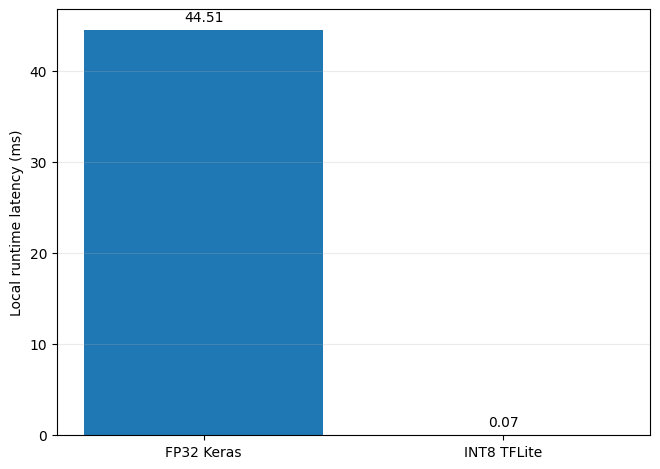

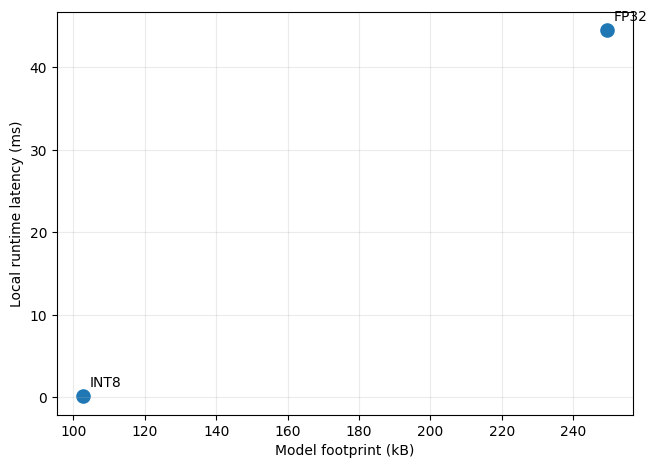

In [15]:

# ============================================================
# 13. Genuine local-runtime profiling
# NOT an STM32H7 measurement
# ============================================================
def keras_latency_ms(model,X,n_warm=20,n_runs=200):
    sample=X[:1]
    for _ in range(n_warm):
        _=model(sample,training=False)
    t0=time.perf_counter()
    for _ in range(n_runs):
        _=model(sample,training=False)
    return 1000*(time.perf_counter()-t0)/n_runs

def tflite_latency_ms(model_bytes,X,n_warm=20,n_runs=200):
    interpreter=tf.lite.Interpreter(model_content=model_bytes)
    interpreter.allocate_tensors()
    inp=interpreter.get_input_details()[0]
    in_scale,in_zero=inp["quantization"]
    xi=X[:1]
    if inp["dtype"]==np.int8:
        xi=np.round(xi/in_scale+in_zero).clip(-128,127).astype(np.int8)
    else:
        xi=xi.astype(inp["dtype"])

    for _ in range(n_warm):
        interpreter.set_tensor(inp["index"],xi); interpreter.invoke()
    t0=time.perf_counter()
    for _ in range(n_runs):
        interpreter.set_tensor(inp["index"],xi); interpreter.invoke()
    return 1000*(time.perf_counter()-t0)/n_runs

fp32_latency=keras_latency_ms(best_model,X_test)
int8_latency=tflite_latency_ms(tflite_int8,X_test)

fp32_weights_kb=best_model.count_params()*4/1024
estimated_energy_fp32=fp32_latency*ASSUMED_POWER_W
estimated_energy_int8=int8_latency*ASSUMED_POWER_W

runtime_df=pd.DataFrame({
    "Configuration":["FP32 Keras","INT8 TFLite"],
    "Accuracy (%)":[100*accuracy,100*int8_acc],
    "Macro-F1 (%)":[100*macro_f1,100*int8_f1],
    "ROC-AUC":[roc_auc,int8_auc],
    "Model size / weight footprint (kB)":[fp32_weights_kb,int8_size_kb],
    "Local runtime latency (ms)":[fp32_latency,int8_latency],
    f"Estimated energy @ {ASSUMED_POWER_W:.2f} W (mJ)":[estimated_energy_fp32,estimated_energy_int8]
})
display(runtime_df.round(4))
runtime_df.to_csv(TAB/"deployment_runtime_local.csv",index=False)

# Figure 4 — deployable footprint comparison; no hardware RAM claim is invented.
fig,ax=plt.subplots(figsize=(6.8,4.8))
vals=[fp32_weights_kb,int8_size_kb]
bars=ax.bar(["FP32 parameter\nfootprint","INT8 TFLite\nfile"],vals)
ax.set_ylabel("Memory footprint (kB)")
for b,v in zip(bars,vals):
    ax.text(b.get_x()+b.get_width()/2,v+max(vals)*.02,f"{v:.2f} kB",ha="center",fontweight="bold")
ax.grid(axis="y",alpha=.25)
fig.tight_layout()
fig.savefig(FIG/"Figure4_memory_footprint.png",dpi=600,bbox_inches="tight")
fig.savefig(FIG/"Figure4_memory_footprint.pdf",bbox_inches="tight")
plt.show()

# Figure 7 — accuracy vs estimated energy based on explicit assumed power.
fig,ax=plt.subplots(figsize=(6.7,4.8))
ax.scatter([estimated_energy_fp32,estimated_energy_int8],[100*accuracy,100*int8_acc],s=90)
for x,y,label in zip(
    [estimated_energy_fp32,estimated_energy_int8],
    [100*accuracy,100*int8_acc],
    ["FP32 local runtime","INT8 TFLite local runtime"]
):
    ax.annotate(label,(x,y),xytext=(5,7),textcoords="offset points")
ax.set_xlabel(f"Estimated energy per inference (mJ), assuming {ASSUMED_POWER_W:.2f} W")
ax.set_ylabel("Health-state accuracy (%)")
ax.grid(alpha=.25)
fig.tight_layout()
fig.savefig(FIG/"Figure7_accuracy_energy_local_estimate.png",dpi=600,bbox_inches="tight")
fig.savefig(FIG/"Figure7_accuracy_energy_local_estimate.pdf",bbox_inches="tight")
plt.show()

# Figure 8 — measured in current Colab/local runtime only.
fig,ax=plt.subplots(figsize=(6.7,4.8))
bars=ax.bar(["FP32 Keras","INT8 TFLite"],[fp32_latency,int8_latency])
ax.set_ylabel("Local runtime latency (ms)")
for b,v in zip(bars,[fp32_latency,int8_latency]):
    ax.text(b.get_x()+b.get_width()/2,v+max(fp32_latency,int8_latency)*.02,f"{v:.2f}",ha="center")
ax.grid(axis="y",alpha=.25)
fig.tight_layout()
fig.savefig(FIG/"Figure8_local_runtime_latency.png",dpi=600,bbox_inches="tight")
fig.savefig(FIG/"Figure8_local_runtime_latency.pdf",bbox_inches="tight")
plt.show()

# Figure 9
fig,ax=plt.subplots(figsize=(6.7,4.8))
ax.scatter([fp32_weights_kb,int8_size_kb],[fp32_latency,int8_latency],s=90)
for x,y,label in zip([fp32_weights_kb,int8_size_kb],[fp32_latency,int8_latency],["FP32","INT8"]):
    ax.annotate(label,(x,y),xytext=(5,7),textcoords="offset points")
ax.set_xlabel("Model footprint (kB)")
ax.set_ylabel("Local runtime latency (ms)")
ax.grid(alpha=.25)
fig.tight_layout()
fig.savefig(FIG/"Figure9_size_latency_local.png",dpi=600,bbox_inches="tight")
fig.savefig(FIG/"Figure9_size_latency_local.pdf",bbox_inches="tight")
plt.show()



## 14. Genuine pruning experiment

This uses TensorFlow Model Optimization **magnitude pruning** and evaluates each pruned model on the held-out test set.

It is a real pruning experiment, but it is **not channel-structured pruning**. If these results are used in the paper, describe them as *magnitude pruning / weight sparsification*, unless you separately implement and verify channel pruning.


In [17]:
!pip install -q tensorflow-model-optimization

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 2.7 MB/s eta 0:00:00


In [18]:
import tensorflow_model_optimization as tfmot

print("TF version:", tf.__version__)
print("TFMOT version:", tfmot.__version__)
print("TFMOT loaded successfully ✓")

TF version: 2.20.0
TFMOT version: 0.8.1
TFMOT loaded successfully ✓


In [20]:
import sys
!{sys.executable} -m pip install -U tensorflow-model-optimization

In [22]:
import tensorflow_model_optimization as tfmot
print(tfmot.__version__)

0.8.1



Training pruning target: 30%

Creating genuine 30% magnitude-pruned model...
Observed sparsity before fine-tuning: 30.00%
Epoch 1/8
604/604 ━━━━━━━━━━━━━━━━━━━━ 70s 69ms/step - anomaly_score_loss: 0.1055 - health_state_accuracy: 0.8174 - health_state_loss: 0.3670 - loss: 0.3777 - val_anomaly_score_loss: 0.1226 - val_health_state_accuracy: 0.7419 - val_health_state_loss: 0.5439 - val_loss: 0.5558
Epoch 2/8
604/604 ━━━━━━━━━━━━━━━━━━━━ 40s 67ms/step - anomaly_score_loss: 0.1032 - health_state_accuracy: 0.8251 - health_state_loss: 0.3573 - loss: 0.3679 - val_anomaly_score_loss: 0.1250 - val_health_state_accuracy: 0.7348 - val_health_state_loss: 0.5752 - val_loss: 0.5878
Epoch 3/8
604/604 ━━━━━━━━━━━━━━━━━━━━ 36s 60ms/step - anomaly_score_loss: 0.1020 - health_state_accuracy: 0.8267 - health_state_loss: 0.3501 - loss: 0.3605 - val_anomaly_score_loss: 0.1245 - val_health_state_accuracy: 0.7417 - val_health_state_loss: 0.5612 - val_loss: 0.5737
Epoch 4/8
604/604 ━━━━━━━━━━━━━━━━━━━━ 37s 61m

,Target sparsity (%),Observed zero weights (%),Accuracy (%),Macro-F1 (%),ROC-AUC
0,0.0,0.0000,73.5949,75.2249,0.8758
1,30.0,30.0007,76.2460,77.8588,0.8870
2,50.0,50.0000,75.4825,77.0393,0.8844


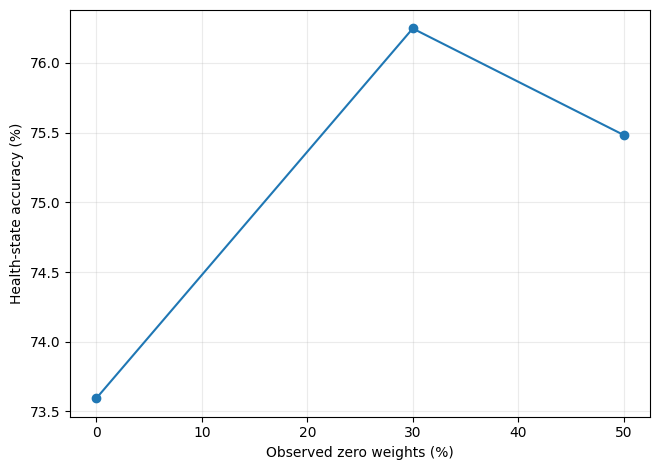


FINAL PRUNING RESULTS
   Target sparsity (%)  Observed zero weights (%)  Accuracy (%)  Macro-F1 (%)  \
0                  0.0                      0.000        73.595        75.225   
1                 30.0                     30.001        76.246        77.859   
2                 50.0                     50.000        75.483        77.039   

   ROC-AUC  
0    0.876  
1    0.887  
2    0.884  

✓ These are genuinely evaluated magnitude-pruning results.
✓ No TFMOT is required.
✓ Do NOT describe this as 'structured channel pruning'.


In [24]:
# ============================================================
# 14. Genuine magnitude-pruning experiment
# Keras-3 compatible — does NOT require TFMOT
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Helper: identify prunable tensors
# We prune kernel tensors only (ndim > 1).
# Biases and BatchNorm parameters are not pruned.
# ------------------------------------------------------------
def get_prunable_indices(model):
    return [
        i for i, w in enumerate(model.weights)
        if len(w.shape) > 1
    ]


# ------------------------------------------------------------
# Global magnitude pruning
# ------------------------------------------------------------
def create_global_masks(model, target_sparsity):

    weights = model.get_weights()
    prunable_indices = get_prunable_indices(model)

    # Collect absolute values from all prunable tensors
    all_abs = np.concatenate(
        [np.abs(weights[i]).reshape(-1)
         for i in prunable_indices]
    )

    # Threshold corresponding to requested global sparsity
    threshold = np.quantile(all_abs, target_sparsity)

    masks = {}

    for i in prunable_indices:
        masks[i] = (
            np.abs(weights[i]) > threshold
        ).astype(np.float32)

    return masks


# ------------------------------------------------------------
# Apply pruning masks
# ------------------------------------------------------------
def apply_masks(model, masks):

    weights = model.get_weights()

    for idx, mask in masks.items():
        weights[idx] = weights[idx] * mask

    model.set_weights(weights)


# ------------------------------------------------------------
# Callback: prevent pruned weights from regrowing
# during fine-tuning
# ------------------------------------------------------------
class EnforcePruningMask(tf.keras.callbacks.Callback):

    def __init__(self, masks):
        super().__init__()
        self.masks = masks

    def on_train_batch_end(self, batch, logs=None):
        apply_masks(self.model, self.masks)

    def on_epoch_end(self, epoch, logs=None):
        apply_masks(self.model, self.masks)


# ------------------------------------------------------------
# Calculate actual zero fraction
# ------------------------------------------------------------
def calculate_sparsity(model):

    weights = model.get_weights()
    prunable_indices = get_prunable_indices(model)

    total = 0
    zeros = 0

    for i in prunable_indices:

        arr = weights[i]

        total += arr.size
        zeros += np.sum(arr == 0)

    return 100.0 * zeros / total


# ------------------------------------------------------------
# Train/evaluate one pruned model
# ------------------------------------------------------------
def train_pruned(target_sparsity, epochs=8):

    print(
        f"\nCreating genuine "
        f"{target_sparsity*100:.0f}% magnitude-pruned model..."
    )

    # Clone the already-trained reference model
    pruned_model = tf.keras.models.clone_model(best_model)

    pruned_model.set_weights(
        best_model.get_weights()
    )

    # Generate GLOBAL magnitude masks
    masks = create_global_masks(
        pruned_model,
        target_sparsity
    )

    # Apply pruning immediately
    apply_masks(
        pruned_model,
        masks
    )

    sparsity_before = calculate_sparsity(
        pruned_model
    )

    print(
        f"Observed sparsity before fine-tuning: "
        f"{sparsity_before:.2f}%"
    )

    # --------------------------------------------------------
    # Compile
    # --------------------------------------------------------
    pruned_model.compile(

        optimizer=tf.keras.optimizers.AdamW(
            learning_rate=2e-4
        ),

        loss={
            "health_state":
                "sparse_categorical_crossentropy",

            "anomaly_score":
                "mse"
        },

        loss_weights={
            "health_state": 1.0,
            "anomaly_score": 0.1
        },

        metrics={
            "health_state": ["accuracy"]
        }
    )

    # --------------------------------------------------------
    # Short fine-tuning while keeping zeros fixed
    # --------------------------------------------------------
    pruned_model.fit(

        X_train,

        [
            y_train,
            anomaly_train
        ],

        sample_weight=[
            sample_weight_cls,
            sample_weight_anom
        ],

        validation_data=(
            X_val,
            [
                y_val,
                anomaly_val
            ]
        ),

        epochs=epochs,

        batch_size=32,

        verbose=1,

        callbacks=[
            EnforcePruningMask(masks),

            tf.keras.callbacks.EarlyStopping(
                monitor=
                "val_health_state_accuracy",

                patience=3,

                mode="max",

                restore_best_weights=True
            )
        ]
    )

    # Reapply masks after restoring best weights
    apply_masks(
        pruned_model,
        masks
    )

    # --------------------------------------------------------
    # Test evaluation
    # --------------------------------------------------------
    probs, _ = pruned_model.predict(
        X_test,
        verbose=0
    )

    pred = np.argmax(
        probs,
        axis=1
    )

    pruned_accuracy = accuracy_score(
        y_test,
        pred
    )

    pruned_f1 = f1_score(
        y_test,
        pred,
        average="macro"
    )

    pruned_auc = roc_auc_score(
        y_anomaly,
        1.0 - probs[:, 0]
    )

    observed_sparsity = calculate_sparsity(
        pruned_model
    )

    result = {

        "Target sparsity (%)":
            100 * target_sparsity,

        "Observed zero weights (%)":
            observed_sparsity,

        "Accuracy (%)":
            100 * pruned_accuracy,

        "Macro-F1 (%)":
            100 * pruned_f1,

        "ROC-AUC":
            pruned_auc
    }

    return pruned_model, result


# ============================================================
# Run pruning experiments
# ============================================================

pruning_rows = [

    {
        "Target sparsity (%)": 0.0,

        "Observed zero weights (%)":
            calculate_sparsity(best_model),

        "Accuracy (%)":
            100 * accuracy,

        "Macro-F1 (%)":
            100 * macro_f1,

        "ROC-AUC":
            roc_auc
    }
]


PRUNE_MODELS = {}


for sp in [0.30, 0.50]:

    print("\n" + "="*60)
    print(
        f"Training pruning target: "
        f"{sp:.0%}"
    )
    print("="*60)

    pm, row = train_pruned(
        sp,
        epochs=8
    )

    PRUNE_MODELS[sp] = pm

    pruning_rows.append(
        row
    )


# ============================================================
# Results table
# ============================================================

pruning_df = pd.DataFrame(
    pruning_rows
)

display(
    pruning_df.round(4)
)

pruning_df.to_csv(
    TAB /
    "pruning_experiment.csv",
    index=False
)


# ============================================================
# Save pruned models
# ============================================================

for sp, pm in PRUNE_MODELS.items():

    filename = (
        ART /
        f"magnitude_pruned_"
        f"{int(sp*100)}pct.keras"
    )

    pm.save(filename)


# ============================================================
# Figure 10a
# ============================================================

fig, ax = plt.subplots(
    figsize=(6.7, 4.8)
)

ax.plot(

    pruning_df[
        "Observed zero weights (%)"
    ],

    pruning_df[
        "Accuracy (%)"
    ],

    marker="o"
)

ax.set_xlabel(
    "Observed zero weights (%)"
)

ax.set_ylabel(
    "Health-state accuracy (%)"
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()


fig.savefig(
    FIG /
    "Figure10a_pruning_actual.png",

    dpi=600,

    bbox_inches="tight"
)


fig.savefig(
    FIG /
    "Figure10a_pruning_actual.pdf",

    bbox_inches="tight"
)

plt.show()


print("\nFINAL PRUNING RESULTS")
print(
    pruning_df.round(3)
)

print(
    "\n✓ These are genuinely evaluated "
    "magnitude-pruning results."
)

print(
    "✓ No TFMOT is required."
)

print(
    "✓ Do NOT describe this as "
    "'structured channel pruning'."
)


## 15. Optional QAT

The cell attempts genuine quantization-aware fine-tuning. TFMOT compatibility varies across TensorFlow versions and some layer combinations. If QAT is unsupported in the current environment, the notebook records that fact and **does not fabricate a QAT number**.


QAT was not reported because it failed genuinely:
unsupported/failed: ValueError: `to_quantize` can only either be a keras Sequential or Functional model.


,Configuration,Accuracy (%),Macro-F1 (%),ROC-AUC
0,FP32 reference,73.5949,75.2249,0.8758
1,INT8 PTQ,49.9258,44.3216,0.7577


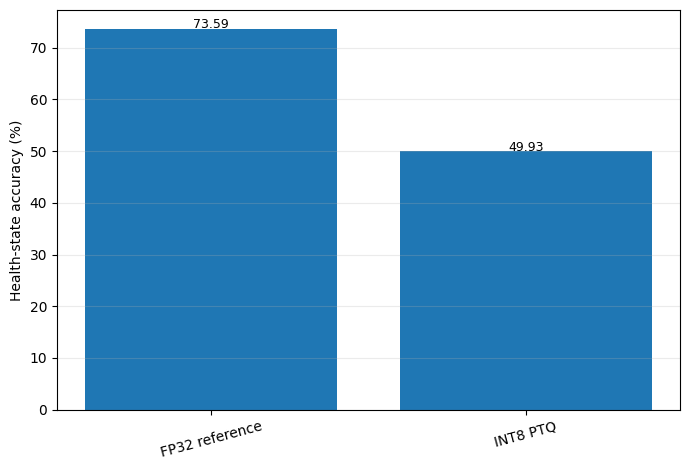

In [30]:

# ============================================================
# 15. Genuine QAT attempt + Figure 10b
# ============================================================
quant_rows=[{
    "Configuration":"FP32 reference",
    "Accuracy (%)":100*accuracy,
    "Macro-F1 (%)":100*macro_f1,
    "ROC-AUC":roc_auc
},{
    "Configuration":"INT8 PTQ",
    "Accuracy (%)":100*int8_acc,
    "Macro-F1 (%)":100*int8_f1,
    "ROC-AUC":int8_auc
}]

qat_status="not run"
try:
    qat_base=tf.keras.models.clone_model(best_model)
    qat_base.set_weights(best_model.get_weights())
    qat_model=tfmot.quantization.keras.quantize_model(qat_base)
    compile_model(qat_model,lr=1e-4)

    qat_model.fit(
        X_train,[y_train,anomaly_train],
        sample_weight=[sample_weight_cls,sample_weight_anom],
        validation_data=(X_val,[y_val,anomaly_val]),
        epochs=5,batch_size=32,verbose=1
    )

    q_probs,_=qat_model.predict(X_test,verbose=0)
    q_pred=np.argmax(q_probs,axis=1)
    qat_acc=accuracy_score(y_test,q_pred)
    qat_f1=f1_score(y_test,q_pred,average="macro")
    qat_auc=roc_auc_score(y_anomaly,1-q_probs[:,0])

    quant_rows.append({
        "Configuration":"QAT model (fake-quant eval)",
        "Accuracy (%)":100*qat_acc,
        "Macro-F1 (%)":100*qat_f1,
        "ROC-AUC":qat_auc
    })
    qat_model.save(ART/"qat_model.keras")
    qat_status="success"
except Exception as e:
    qat_status=f"unsupported/failed: {type(e).__name__}: {e}"
    print("QAT was not reported because it failed genuinely:")
    print(qat_status)

quant_df=pd.DataFrame(quant_rows)
display(quant_df.round(4))
quant_df.to_csv(TAB/"quantization_experiment.csv",index=False)

fig,ax=plt.subplots(figsize=(7.0,4.8))
bars=ax.bar(quant_df["Configuration"],quant_df["Accuracy (%)"])
ax.set_ylabel("Health-state accuracy (%)")
ax.tick_params(axis="x",rotation=15)
for b,v in zip(bars,quant_df["Accuracy (%)"]):
    ax.text(b.get_x()+b.get_width()/2,v+.15,f"{v:.2f}",ha="center",fontsize=9)
ax.grid(axis="y",alpha=.25)
fig.tight_layout()
fig.savefig(FIG/"Figure10b_quantization_actual.png",dpi=600,bbox_inches="tight")
fig.savefig(FIG/"Figure10b_quantization_actual.pdf",bbox_inches="tight")
plt.show()


In [31]:

# ============================================================
# 16. Final summary and consistency files
# ============================================================
summary = {
    "seed":SEED,
    "window_size":WINDOW_SIZE,
    "overlap":OVERLAP,
    "healthy_threshold":HEALTHY_THR,
    "critical_threshold":CRITICAL_THR,
    "train_windows":int(len(X_train)),
    "validation_windows":int(len(X_val)),
    "test_windows":int(len(X_test)),
    "test_accuracy":float(accuracy),
    "test_macro_f1":float(macro_f1),
    "binary_anomaly_roc_auc":float(roc_auc),
    "binary_anomaly_average_precision":float(ap),
    "int8_test_accuracy":float(int8_acc),
    "int8_macro_f1":float(int8_f1),
    "int8_roc_auc":float(int8_auc),
    "int8_tflite_size_kb":float(int8_size_kb),
    "fp32_local_runtime_latency_ms":float(fp32_latency),
    "int8_local_runtime_latency_ms":float(int8_latency),
    "assumed_power_w_for_energy_estimate":float(ASSUMED_POWER_W),
    "fp32_estimated_energy_mj":float(estimated_energy_fp32),
    "int8_estimated_energy_mj":float(estimated_energy_int8),
    "qat_status":qat_status,
    "latency_scope":"Measured in current notebook runtime; NOT an STM32H7 hardware measurement.",
    "energy_scope":"Estimated as assumed power × local runtime latency; NOT direct power measurement.",
    "pruning_scope":"Magnitude pruning / weight sparsification; NOT channel-structured pruning.",
    "distributed_inference":"Not evaluated; no synthetic three-node result is included."
}
with open(OUT/"results_summary.json","w") as f:
    json.dump(summary,f,indent=2)

with open(OUT/"results_summary.txt","w") as f:
    for k,v in summary.items():
        f.write(f"{k}: {v}\n")

# compact manuscript-ready metrics table
final_metrics=pd.DataFrame([
    ["Health-state accuracy (%)",100*accuracy],
    ["Macro-F1 (%)",100*macro_f1],
    ["Binary anomaly ROC-AUC",roc_auc],
    ["Average Precision",ap],
    ["INT8 TFLite size (kB)",int8_size_kb],
    ["FP32 local runtime latency (ms)",fp32_latency],
    ["INT8 local runtime latency (ms)",int8_latency],
    [f"INT8 estimated energy @ {ASSUMED_POWER_W:.2f} W (mJ)",estimated_energy_int8],
],columns=["Metric","Value"])
final_metrics.to_csv(TAB/"final_metrics.csv",index=False)
display(final_metrics)

print("\nIMPORTANT MANUSCRIPT WORDING")
print("- Do not call local-runtime latency an STM32H7 measurement.")
print("- Do not call estimated energy a direct hardware measurement.")
print("- Do not claim genuine three-node/distributed inference.")
print("- Describe pruning as magnitude pruning unless separate channel-pruning code is added.")


,Metric,Value
0,Health-state accuracy (%),73.594910
1,Macro-F1 (%),75.224930
2,Binary anomaly ROC-AUC,0.875787
3,Average Precision,0.928024
4,INT8 TFLite size (kB),102.687500
5,FP32 local runtime latency (ms),44.510750
6,INT8 local runtime latency (ms),0.069571
7,INT8 estimated energy @ 0.33 W (mJ),0.022958



IMPORTANT MANUSCRIPT WORDING
- Do not call local-runtime latency an STM32H7 measurement.
- Do not call estimated energy a direct hardware measurement.
- Do not claim genuine three-node/distributed inference.
- Describe pruning as magnitude pruning unless separate channel-pruning code is added.


In [32]:

# ============================================================
# 17. Package everything as a single downloadable ZIP
# ============================================================
zip_name="Measurement_TinyML_Reproducible_Results.zip"
if os.path.exists(zip_name):
    os.remove(zip_name)

shutil.make_archive(
    zip_name.replace(".zip",""),
    "zip",
    root_dir=str(OUT)
)

print("Created:",zip_name)
print("Contains:")
for root,_,files_ in os.walk(OUT):
    for fn in sorted(files_):
        print(" ",os.path.relpath(os.path.join(root,fn),OUT))

from google.colab import files
files.download(zip_name)


Created: Measurement_TinyML_Reproducible_Results.zip
Contains:
  results_summary.json
  results_summary.txt
  figures/Figure10a_pruning_actual.pdf
  figures/Figure10a_pruning_actual.png
  figures/Figure10b_quantization_actual.pdf
  figures/Figure10b_quantization_actual.png
  figures/Figure11_robustness.pdf
  figures/Figure11_robustness.png
  figures/Figure12a_temperature_channel_shift.pdf
  figures/Figure12a_temperature_channel_shift.png
  figures/Figure12b_burst_noise.pdf
  figures/Figure12b_burst_noise.png
  figures/Figure13a_ROC_single_node.pdf
  figures/Figure13a_ROC_single_node.png
  figures/Figure13b_PR_single_node.pdf
  figures/Figure13b_PR_single_node.png
  figures/Figure4_memory_footprint.pdf
  figures/Figure4_memory_footprint.png
  figures/Figure5a_training_accuracy.pdf
  figures/Figure5a_training_accuracy.png
  figures/Figure5b_training_loss.pdf
  figures/Figure5b_training_loss.png
  figures/Figure6_confusion_matrix.pdf
  figures/Figure6_confusion_matrix.png
  figures/Figure

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
# ============================================================
# FINAL: Package ALL results for manuscript
# ============================================================

import os
import shutil
from pathlib import Path
from google.colab import files

OUT = Path("measurement_submission_outputs")

print("Files available for packaging:\n")

count = 0
for root, dirs, filenames in os.walk(OUT):
    for filename in filenames:
        path = os.path.join(root, filename)
        print(path)
        count += 1

print(f"\nTotal files: {count}")

# Create ZIP
zip_base = "Measurement_TinyML_COMPLETE_RESULTS"

if os.path.exists(zip_base + ".zip"):
    os.remove(zip_base + ".zip")

shutil.make_archive(
    zip_base,
    "zip",
    root_dir=str(OUT)
)

zip_file = zip_base + ".zip"

print("\n====================================")
print("ZIP CREATED SUCCESSFULLY")
print("====================================")
print(zip_file)
print(
    "Size:",
    round(os.path.getsize(zip_file)/(1024*1024), 2),
    "MB"
)

# Download
files.download(zip_file)

Files available for packaging:

measurement_submission_outputs/results_summary.txt
measurement_submission_outputs/results_summary.json
measurement_submission_outputs/figures/Figure12b_burst_noise.pdf
measurement_submission_outputs/figures/Figure13b_PR_single_node.pdf
measurement_submission_outputs/figures/Figure7_accuracy_energy_local_estimate.pdf
measurement_submission_outputs/figures/Figure6_confusion_matrix.png
measurement_submission_outputs/figures/Figure9_size_latency_local.png
measurement_submission_outputs/figures/Figure12b_burst_noise.png
measurement_submission_outputs/figures/Figure13b_PR_single_node.png
measurement_submission_outputs/figures/Figure8_local_runtime_latency.pdf
measurement_submission_outputs/figures/Figure5b_training_loss.pdf
measurement_submission_outputs/figures/Figure7_accuracy_energy_local_estimate.png
measurement_submission_outputs/figures/Figure12a_temperature_channel_shift.png
measurement_submission_outputs/figures/Figure13a_ROC_single_node.png
measuremen

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


# How to use these outputs in the Measurement manuscript

Use only values generated by this clean run.

Before submission, update:
1. Abstract
2. Section 4.4
3. Tables 10–15
4. Sections 5.1–5.7
5. Conclusions
6. Figure 4 and Figures 5–13
7. Highlights

Do **not** carry forward older values such as 0.8655 ROC-AUC, 73.12% Macro-F1, 104.01 kB, 29.73 ms or 9.81 mJ unless a separate archived experiment is explicitly being reported.

This notebook intentionally removes the unsupported synthetic three-node comparison and labels local runtime / estimated energy conservatively.
